In [1]:
import sys
from pathlib import Path
# Make the repo root importable regardless of CWD or machine: walk up from the
# working dir until we hit a repo marker, then put that dir on sys.path.
_start = Path.cwd()
_root = next((p for p in (_start, *_start.parents)
              if (p / ".git").exists() or (p / "setup.py").exists()), _start)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
from metab_processing.metab_travlr_config import DATA_DIR


PROJECT = 'Alexi_UC_Spliced'
PROJECT_DIR = f'{DATA_DIR}/{PROJECT}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# --- Sample registry & core helpers ------------------------------------------
# Every spacetravlr adata: sample name -> dataset folder under PROJECT_DIR. Add rows
# to bring in more samples.
SAMPLES = {
    'Slice 1': '13473_HS4_UC-Slice_1',
    'Slice 2': '13473_HS4_UC-Slice_2',
    'Slice 3': '13473_HS4_UC-Slice_3',
    'Slice 4': '13473_HS4_UC-Slice_4',
}

ADATAS = {}   # cache: sample name -> loaded, betax-processed adata (filled by get_adata)


def sample_dir(sample):
    """Absolute data dir for a registered sample name."""
    return f'{PROJECT_DIR}/{SAMPLES[sample]}'


def add_betax(adata, gene=None):
    """Attach beta*x for the metabolite modulators to adata.obsm['betax_<gene>'] (names in
    adata.uns['betax_modulators'][gene]). `x` is the per-cell metab communication score in
    adata.obsm['x_metab']; tf/lr/ltf modulators have no x and are skipped."""
    x = adata.obsm['x_metab']
    x_idx = {m: i for i, m in enumerate(adata.uns['x_metab_modulators'])}
    betax_mods = adata.uns.setdefault('betax_modulators', {})
    genes = list(adata.uns['beta_modulators']) if gene is None else [gene]
    for g in genes:
        mods = list(adata.uns['beta_modulators'][g])
        beta = adata.obsm[f'beta_{g}']
        cols, names = [], []
        for j, m in enumerate(mods):
            if m in x_idx:
                cols.append(beta[:, j] * x[:, x_idx[m]]); names.append(m)
        adata.obsm[f'betax_{g}'] = (np.column_stack(cols) if cols
                                    else np.empty((adata.n_obs, 0), dtype=beta.dtype))
        betax_mods[g] = names
    return adata


def load_sample_adata(sample):
    """Read a sample's spacetravlr adata and stamp its name onto uns['sample']."""
    ad = sc.read_h5ad(f'{sample_dir(sample)}/spacetravlr_adata.h5ad')
    ad.uns['sample'] = sample
    return ad


def get_adata(sample):
    """Return the sample's betax-processed adata, loading + caching in ADATAS on first use."""
    if sample not in ADATAS:
        ad = load_sample_adata(sample)
        assert 'x_metab' in ad.obsm, (
            f"{sample}: adata.obsm['x_metab'] missing -- re-run the run_spacetravlr artifacts "
            f"stage, or comment out this sample's load.")
        add_betax(ad)
        ADATAS[sample] = ad
    return ADATAS[sample]


def _mod_index(names, name):
    """Column index of `name` in a modulator-name array. Raises (does NOT silently return 0)
    if absent -- catches typos like 'Fatty Acid' vs 'Fatty acid'."""
    names = list(names)
    if name not in names:
        raise KeyError(f"{name!r} not found among {len(names)} modulators; e.g. {names[:6]}")
    return names.index(name)


def _ct_label(cell_types):
    """Readable cell-type tag for chart titles."""
    return 'all cells' if cell_types is None else ', '.join(cell_types)

In [5]:
# This is for loading the coefficients into the adata, which requires spacetravlr to be installed (or at least some of its required arrays)

# adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
# adata

# from metab_processing.SpaceTravLR import beta_analysis

# betadata_dir = f'{DATA_DIR}/spacetravlr_output/betadata'
# beta_analysis.betas_to_adata(adata, betadata_dir, group=None)
# print(adata)
# adata.write_h5ad(f"{DATA_DIR}/spacetravlr_adata.h5ad")
# del adata

In [4]:
# ============================ SETTINGS ============================
TIER = '25_06_11_ICI_5K_Coarse_annotations'   # cell-type annotation column (hard-coded)
CELL_TYPE = 'IEC'                              # cell type the single-sample cells focus on
GENE = 'NDRG1'                                 # primary target gene
# GENE = 'RORC'

# Load every sample once (betax processed, cached in ADATAS). Comment out a line to
# skip a sample (e.g. to save RAM); the multi-sample cells iterate whatever is loaded.
adata1 = get_adata('Slice 1')
adata2 = get_adata('Slice 2')
adata3 = get_adata('Slice 3')
adata4 = get_adata('Slice 4')

adata = adata1                       # <- sample the single-sample cells use; switch to adata2/3/4
DATASET_NAME = adata.uns['sample']
DATA_DIR = sample_dir(DATASET_NAME)
print('loaded:', list(ADATAS)); adata

loaded: ['Slice 1', 'Slice 2', 'Slice 3', 'Slice 4']


AnnData object with n_obs × n_vars = 12142 × 4736
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'orientation_cores', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'leiden', 'leiden_res_1_5', 'leiden_res_1_3', 'leiden_res_1_4', 'leiden_res_1_6', 'leiden_res_1_2', '25_06_11_ICI_5K_Compartments', '24_11_12_ICI_5K_Fine_annotations', '25_06_11_ICI_5K_Coarse_annotations', '240927_Condition', '25_06_11_Patient_ID_HS', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_c

/tmp/ipykernel_3940743/3874655390.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color=TIER);


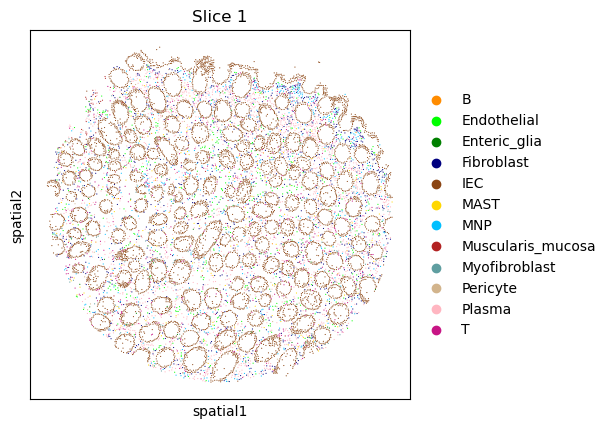

In [5]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color=TIER);

In [6]:
list(adata.uns['beta_modulators'])

['ATP1A1',
 'CD3E',
 'CD3G',
 'CD4',
 'CSF2',
 'CTLA4',
 'ENTPD1',
 'FOXP3',
 'HAVCR2',
 'HIF1A',
 'IL10',
 'IL17A',
 'IL17F',
 'IL23R',
 'IL2RA',
 'LAG3',
 'MAPK11',
 'MAPK12',
 'MAPK14',
 'MYC',
 'NDRG1',
 'PDCD1',
 'RORC',
 'SCNN1A',
 'SCNN1G',
 'SGK1',
 'SLC5A1',
 'SLC9A3',
 'TBP',
 'TCF7',
 'TOX']

In [7]:
# metabolite + other modulators learned for the primary GENE
adata.uns['beta_modulators'][GENE]

array(['AHR', 'AHRR', 'ARNT', 'ATF3', 'ATF4', 'BATF', 'BCL3', 'CREB1',
       'CTCF', 'CTCFL', 'E2F1', 'E2F3', 'E2F4', 'EGR2', 'EHF', 'ELK1',
       'ELK3', 'ELK4', 'EP300', 'ERG', 'ETS1', 'ETV1', 'ETV5', 'ETV6',
       'FEV', 'FLI1', 'FOSL1', 'FOXA1', 'FOXA2', 'FOXC1', 'FOXC2',
       'FOXE1', 'FOXE3', 'FOXI1', 'FOXJ2', 'FOXL2', 'FOXO1', 'FOXO3',
       'FOXO4', 'FOXP1', 'FOXP2', 'FOXP3', 'FOXP4', 'GATA1', 'GATA2',
       'HDAC2', 'HES1', 'HES4', 'HMGN3', 'HNF4A', 'IRF1', 'IRF4', 'JDP2',
       'JUN', 'KLF12', 'KLF14', 'KLF16', 'KLF4', 'KLF5', 'MAX', 'MEF2A',
       'MEF2C', 'NANOG', 'NFATC1', 'NFKB1', 'NR1I2', 'NR1I3', 'NR3C1',
       'NRF1', 'PAX1', 'PAX2', 'PAX5', 'PAX8', 'PBX3', 'POU5F1', 'PRDM1',
       'REST', 'RXRA', 'SALL4', 'SETDB1', 'SIN3A', 'SMAD1', 'SMARCA5',
       'SMARCB1', 'SMARCC1', 'SMC3', 'SOX18', 'SP1', 'SP3', 'SRF',
       'STAT1', 'STAT2', 'STAT3', 'TAF1', 'TAL1', 'TBP', 'TCF7L2',
       'TFAP2A', 'TFAP2B', 'TRIM28', 'TWIST1', 'TWIST2', 'WT1', 'YY1',
       'ZBTB

In [8]:
def plot_beta(adata, gene, modulator, tier, cell_types=None, spot_size=35):
    i = _mod_index(adata.uns['beta_modulators'][gene], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    sub.obs['beta'] = sub.obsm[f'beta_{gene}'][:, i]
    sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
                  title=f"{adata.uns.get('sample','')} | {gene} ~ {modulator} | {_ct_label(cell_types)}")

/tmp/ipykernel_3940743/4058843177.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_3940743/4058843177.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_3940743/4058843177.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_3940743/4058843177.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,


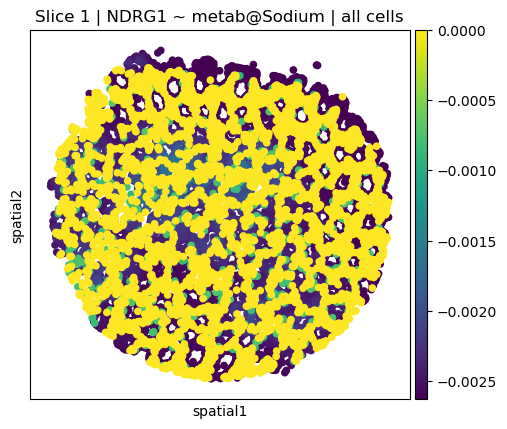

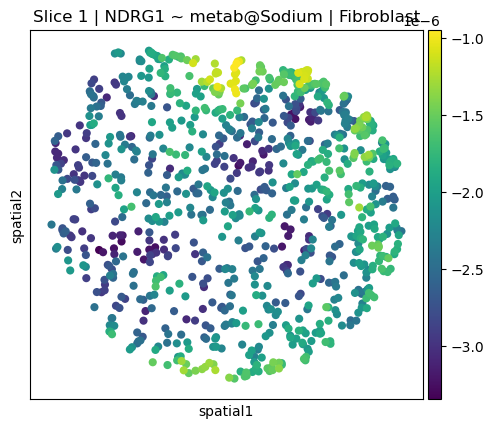

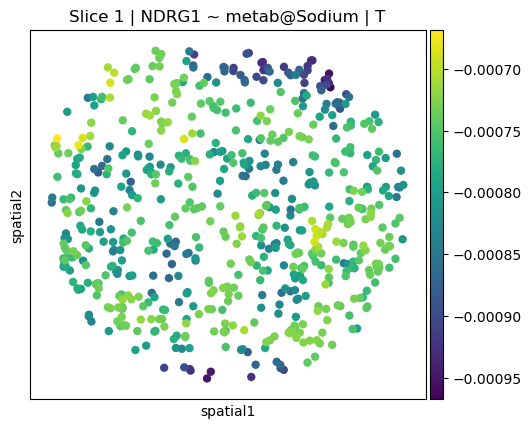

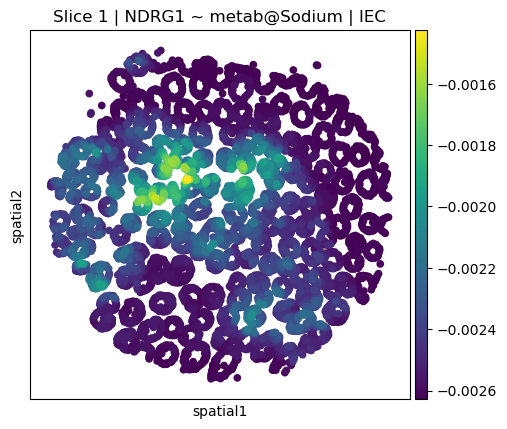

In [9]:
# gp = [m for m in adata.uns['beta_modulators'][GENE] if '@' in m][1]
gp = 'metab@Sodium'
plot_beta(adata, GENE, gp, TIER)
plot_beta(adata, GENE, gp, TIER, ['Fibroblast'])
plot_beta(adata, GENE, gp, TIER, ['T'])
plot_beta(adata, GENE, gp, TIER, ['IEC'])

In [10]:
# Same spatial plot as plot_beta, but for the metabolite x (communication score) and for
# beta * x. Requires the re-run adata (obsm['x_metab'] + add_betax already applied).
def plot_x(adata, modulator, tier, cell_types=None, spot_size=35):
    i = _mod_index(adata.uns['x_metab_modulators'], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    sub.obs['x'] = sub.obsm['x_metab'][:, i]
    sc.pl.spatial(sub, color='x', spot_size=spot_size, show=False,
                  title=f"{adata.uns.get('sample','')} | x ~ {modulator} | {_ct_label(cell_types)}")


def plot_betax(adata, gene, modulator, tier, cell_types=None, spot_size=35):
    i = _mod_index(adata.uns['betax_modulators'][gene], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    sub.obs['betax'] = sub.obsm[f'betax_{gene}'][:, i]
    sc.pl.spatial(sub, color='betax', spot_size=spot_size, show=False,
                  title=f"{adata.uns.get('sample','')} | {gene} ~ {modulator} beta*x | {_ct_label(cell_types)}")

/tmp/ipykernel_3927030/666495285.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='x', spot_size=spot_size, show=False,
/tmp/ipykernel_3927030/666495285.py:17: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='betax', spot_size=spot_size, show=False,


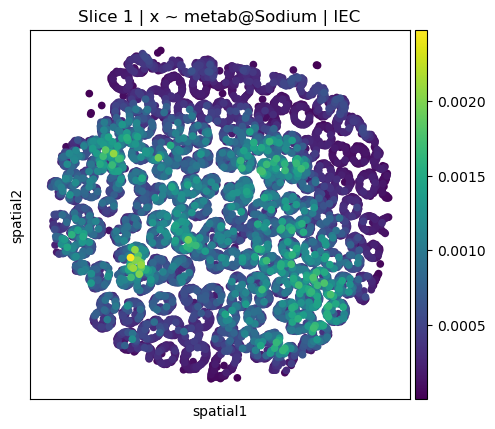

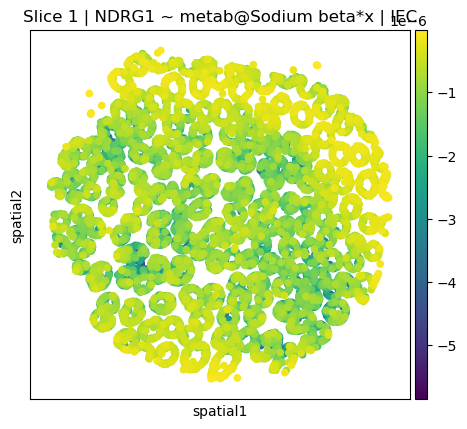

In [14]:
plot_x(adata, 'metab@Sodium', TIER, cell_types=['IEC'])
plot_betax(adata, GENE, 'metab@Sodium', TIER, cell_types=['IEC'])

In [11]:
def get_betas_modulator(adata, gene, modulator, tier=None, cell_types=None):
    i = _mod_index(adata.uns['beta_modulators'][gene], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    return sub.obsm[f'beta_{gene}'][:, i]

def agg_modulator(adata, gene, modulator, tier=None, cell_types=None):
    betas = get_betas_modulator(adata, gene, modulator, tier, cell_types)
    return np.mean(betas), np.std(betas)

agg_modulator(adata, GENE, 'NFKB1', TIER, cell_types=['IEC'])
        

(np.float32(0.22868206), np.float32(0.15449575))

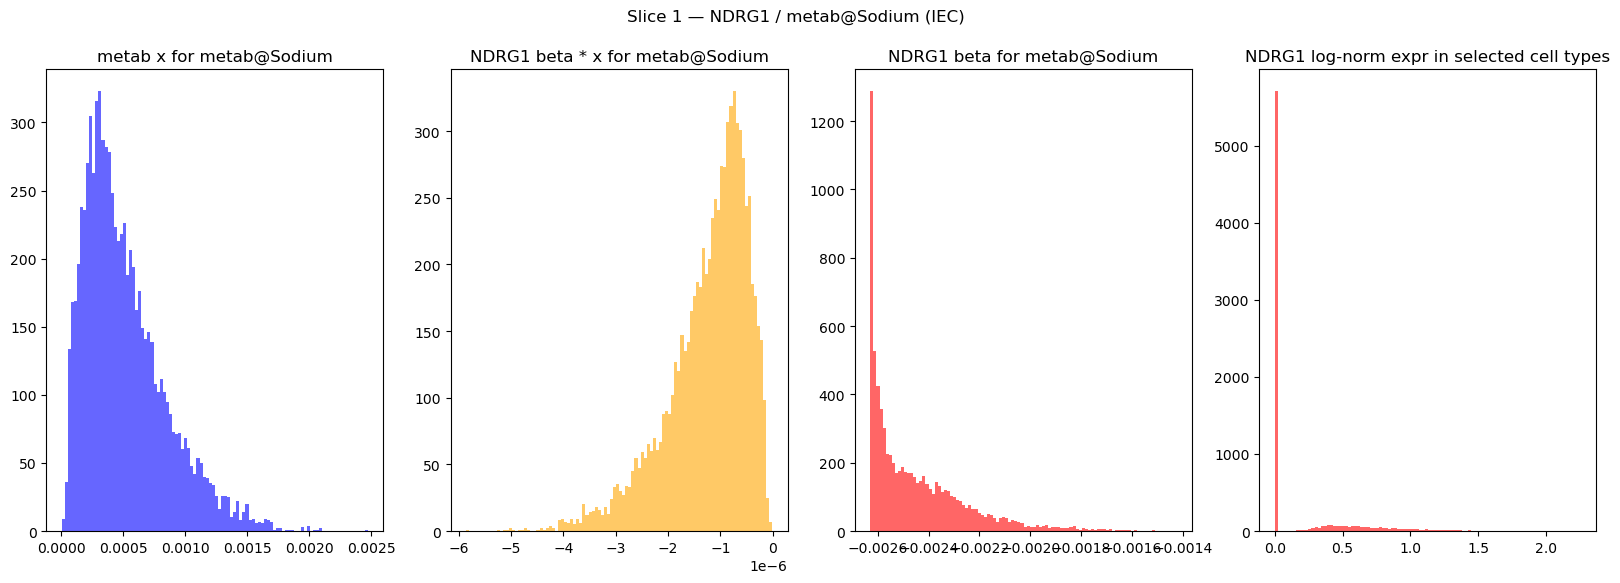

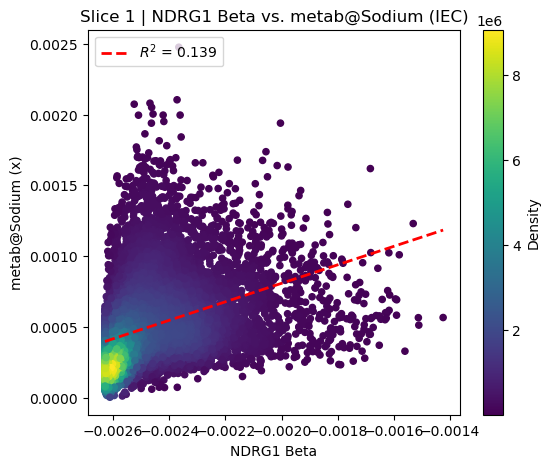

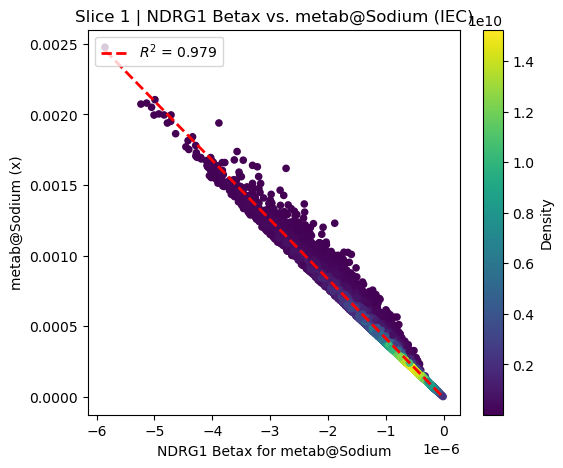

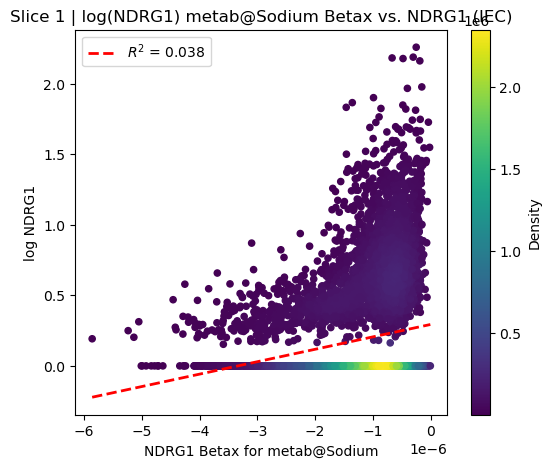

In [21]:
from scipy.stats import gaussian_kde
from scipy.stats import linregress

adata = adata1
MY_GENE = 'NDRG1'
# MY_GENE = 'RORC'
# MY_GENE = 'MYC'
# MY_GENE = 'SCNN1A'
# MY_GENE = 'CD3E'
# MY_GENE = 'SLC9A3'
MY_METAB = 'metab@Sodium'
# MY_METAB = 'metab@Water'
# MY_METAB = 'metab@Fatty acid'


def get_metab_x_modulator(adata, modulator, tier, cell_types=None):
    i = _mod_index(adata.uns['x_metab_modulators'], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    return sub.obsm['x_metab'][:, i]

def get_betax_modulator(adata, gene, modulator, tier, cell_types=None):
    i = _mod_index(adata.uns['betax_modulators'][gene], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    return sub.obsm[f'betax_{gene}'][:, i]

# Fetch the data
data_beta = get_betas_modulator(adata, MY_GENE, MY_METAB, TIER, cell_types=[CELL_TYPE])
data_metab = get_metab_x_modulator(adata, MY_METAB, TIER, cell_types=[CELL_TYPE])
data_betax = get_betax_modulator(adata, MY_GENE, MY_METAB, TIER, cell_types=[CELL_TYPE])
data_target = adata[adata.obs[TIER] == CELL_TYPE][:, MY_GENE].layers['log_normalized_counts'].toarray().flatten()  # adata.X is raw counts

# Plot side-by-side
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 6))

ax1.hist(data_metab, alpha=0.6, color='blue', bins=100)
ax1.set_title(f'metab x for {MY_METAB}')

ax2.hist(data_betax, alpha=0.6, color='orange', bins=100)
ax2.set_title(f'{MY_GENE} beta * x for {MY_METAB}')

ax3.hist(data_beta, alpha=0.6, color='red', bins=100)
ax3.set_title(f'{MY_GENE} beta for {MY_METAB}')

ax4.hist(data_target, alpha=0.6, color='red', bins=100)
ax4.set_title(f'{MY_GENE} log-norm expr in selected cell types')
fig.suptitle(f'{adata.uns.get("sample","")} \u2014 {MY_GENE} / {MY_METAB} ({CELL_TYPE})')

def plot_density_scatter(x_data, y_data, xlabel="X", ylabel="Y", title="Density Scatter Plot"):
    # Flatten and filter NaNs
    x, y = np.ravel(x_data), np.ravel(y_data)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    
    # Calculate density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    # Linear regression for trendline and R^2
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r_squared = r_value**2

    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(x, y, c=z, s=20, cmap='viridis')
    
    # Trendline
    x_seq = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_seq, slope * x_seq + intercept, color='red', linestyle='--', 
            linewidth=2, label=f'$R^2$ = {r_squared:.3f}')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='upper left')
    
    plt.colorbar(sc, ax=ax, label='Density')
    plt.show()

plot_density_scatter(
    x_data=data_beta,
    y_data=data_metab,
    xlabel=f'{MY_GENE} Beta',
    ylabel=f'{MY_METAB} (x)',
    title=f'{adata.uns.get("sample","")} | {MY_GENE} Beta vs. {MY_METAB} ({CELL_TYPE})'
)

plot_density_scatter(
    x_data=data_betax,
    y_data=data_metab,
    xlabel=f'{MY_GENE} Betax for {MY_METAB}',
    ylabel=f'{MY_METAB} (x)',
    title=f'{adata.uns.get("sample","")} | {MY_GENE} Betax vs. {MY_METAB} ({CELL_TYPE})'
)

plot_density_scatter(
    x_data=data_betax,
    y_data=data_target,
    xlabel=f'{MY_GENE} Betax for {MY_METAB}',
    ylabel=f'log {MY_GENE}',
    title=f'{adata.uns.get("sample","")} | log({MY_GENE}) {MY_METAB} Betax vs. {MY_GENE} ({CELL_TYPE})'
)

In [22]:
# One row per (target gene, metabolite): R^2 of that pair's beta*x against the gene's
# log-normalized expression, plus fixed summary stats (no layer switch):
#   avg_abs_beta -- mean |beta| (raw coefficient)
#   avg_betax    -- mean beta*x (the coefficient's contribution)
#   avg_x        -- mean metabolite communication score x (adata.obsm['x_metab'])
#   avg_raw_expr -- mean of RAW counts        (adata.X)          -- same for a gene's metabs
#   var_log_expr -- variance of LOG expression (log_normalized_counts) -- same for a gene's metabs
# NaN betas/expression dropped per pair; <3 valid cells or constant beta*x/expr -> NaN R^2.
def betax_vs_gene_r2(adata, tier, cell_types=None, genes=None):
    genes = list(adata.uns['betax_modulators']) if genes is None else genes
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    x_idx = {m: i for i, m in enumerate(adata.uns['x_metab_modulators'])}
    rows = []
    for g in genes:
        raw = sub[:, g].X.toarray().ravel()                                    # raw counts
        logx = sub[:, g].layers['log_normalized_counts'].toarray().ravel()     # log-normalized
        avg_raw_expr, var_log_expr = float(np.nanmean(raw)), float(np.nanvar(logx))
        beta = sub.obsm[f'beta_{g}']
        beta_mods = list(adata.uns['beta_modulators'][g])
        bx = sub.obsm[f'betax_{g}']
        xm = sub.obsm['x_metab']
        for j, metab in enumerate(adata.uns['betax_modulators'][g]):
            bxj = bx[:, j]
            b = beta[:, beta_mods.index(metab)]
            xj = xm[:, x_idx[metab]]
            m = ~np.isnan(bxj) & ~np.isnan(logx)
            ok = m.sum() >= 3 and np.ptp(bxj[m]) > 0 and np.ptp(logx[m]) > 0
            r2 = linregress(bxj[m], logx[m]).rvalue ** 2 if ok else np.nan
            rows.append({'gene': g, 'metabolite': metab, 'r2': r2,
                         'avg_abs_beta': float(np.nanmean(np.abs(b))),
                         'avg_betax': float(np.nanmean(bxj)),
                         'avg_x': float(np.nanmean(xj)),
                         'avg_raw_expr': avg_raw_expr,
                         'var_log_expr': var_log_expr,
                         'n_cells': int(m.sum())})
    return pd.DataFrame(rows).sort_values('r2', ascending=False, ignore_index=True)

In [23]:
betax_r2 = betax_vs_gene_r2(adata, TIER, cell_types=[CELL_TYPE])

# Re-order by a different field -- uncomment one:
# betax_r2 = betax_r2.sort_values('avg_abs_beta', ascending=False, ignore_index=True)
# betax_r2 = betax_r2.sort_values('avg_betax',    ascending=False, ignore_index=True)
# betax_r2 = betax_r2.sort_values('avg_x',        ascending=False, ignore_index=True)
# betax_r2 = betax_r2.sort_values('avg_raw_expr', ascending=False, ignore_index=True)
# betax_r2 = betax_r2.sort_values('var_log_expr', ascending=False, ignore_index=True)
betax_r2.head(50)

,gene,metabolite,r2,avg_abs_beta,avg_betax,avg_x,avg_raw_expr,var_log_expr,n_cells
0,SLC9A3,metab@Anion exchange,0.645414,3.642627,8.563649e-03,2.342202e-03,0.521857,0.154394,7778
1,SLC9A3,metab@Sodium_hydrogen exchange,0.633653,0.005484,5.212225e-06,7.637909e-04,0.521857,0.154394,7778
2,SLC9A3,metab@4-ene-Valproic acid,0.582461,0.033723,2.023503e-06,5.929063e-05,0.521857,0.154394,7778
3,SLC9A3,metab@Acetyl-L-Carnitine|Choline|Creatine|Dopa...,0.582157,0.014958,4.482639e-07,2.754566e-05,0.521857,0.154394,7778
4,SLC9A3,metab@L-Carnitine,0.577309,0.038913,1.985576e-06,4.967472e-05,0.521857,0.154394,7778
5,SLC9A3,metab@Nicotinate,0.572491,0.042867,2.873022e-06,6.656240e-05,0.521857,0.154394,7778
6,SLC9A3,metab@Taurocholic acid,0.569918,0.131720,2.482964e-05,1.875678e-04,0.521857,0.154394,7778
7,SLC9A3,metab@Cholic acid,0.563974,0.025220,1.321934e-06,5.002779e-05,0.521857,0.154394,7778
8,SLC9A3,metab@O-Desmethylverapamil (D-702),0.555146,0.209935,6.151477e-05,2.906050e-04,0.521857,0.154394,7778
9,SLC9A3,metab@Amiloride-sensitive sodium transport,0.555124,0.014394,1.362893e-06,5.454083e-05,0.521857,0.154394,7778


In [24]:
# Reshape any per-pair table into a gene x metabolite grid and colour it (a heat map).
# NaN cells (a metabolite that isn't a modulator for that gene) are left blank.
def heatmap_field(df, field='r2', index='metabolite', columns='gene', cmap='viridis'):
    grid = df.pivot(index=index, columns=columns, values=field)
    grid = grid.dropna(how='all').dropna(axis=1, how='all')  # drop fully-empty rows/cols
    return grid.style.background_gradient(cmap=cmap, axis=None).format('{:.3f}', na_rep='')

In [25]:
# R^2 as a coloured gene x metabolite grid. Swap `field` for any column, e.g.
# 'avg_abs_beta', 'avg_betax', 'avg_x', 'avg_raw_expr', 'var_log_expr', 'n_cells'.
heatmap_field(betax_r2, 'r2')

gene,ATP1A1,CD3E,CD3G,CD4,CTLA4,ENTPD1,FOXP3,HIF1A,IL17F,IL23R,IL2RA,MAPK14,MYC,NDRG1,RORC,SCNN1A,SGK1,SLC5A1,SLC9A3,TBP,TCF7,TOX
metabolite,,,,,,,,,,,,,,,,,,,,,,
"metab@(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3-yl-b-D-Glucopyranosiduronic acid|1b,3a,12a-Trihydroxy-5b-cholanoic acid|3-Sulfodeoxycholic acid|3alpha,7alpha-Dihydroxycoprostanic acid|3b-Hydroxy-5-cholenoic acid|Chenodeoxycholic acid|Chenodeoxycholic acid 3-sulfate|Coprocholic acid|Deoxycholic acid|Folinic acid|Glutathione|Glycochenodeoxycholate-3-sulfate|Hyodeoxycholic acid|Isoursodeoxycholic acid|Lithocholic acid|Sulfolithocholic acid|Trihydroxycoprostanoic acid|Ursocholic acid|Ursodeoxycholic acid|Ursodeoxycholic acid 3-sulfate|Varanic acid",0.034,,,,0.000,,,0.001,,,,0.001,0.006,0.124,,0.011,,,0.066,,,
"metab@17a-Ethynylestradiol|3',4'-Dihydrodiol|4'-Hydroxydiclofenac|4-Hydroxycyclophosphamide|8-Hydroxycarvedilol|E-3179|Estriol|Glycerol|N-Desmethylcitalopram|N-Desmethyleletriptan|O-Deethylated candesartan",0.001,,0.000,,0.000,0.000,0.000,0.003,0.000,0.000,0.000,0.000,0.003,0.235,0.002,0.088,0.044,0.002,0.510,0.000,0.000,0.001
metab@2-Hydroxychlorpropamide,0.003,0.000,,0.000,0.000,0.000,0.000,0.002,0.000,0.000,0.000,0.000,0.003,0.230,0.002,0.087,0.040,0.002,0.495,0.001,0.000,0.001
metab@25-Hydroxycholesterol,0.025,,,,,,,,,,,,,0.000,,,,,0.313,,,
metab@4-ene-Valproic acid,0.011,,,0.000,,0.000,,0.003,,0.000,0.000,0.001,0.006,0.253,0.001,0.081,0.002,0.003,0.582,0.000,,0.000
metab@5-Hydroxyomeprazole,0.018,0.000,0.000,0.000,0.000,0.000,0.000,0.003,0.000,0.000,0.000,0.000,0.004,0.247,0.002,0.090,0.019,0.002,0.535,0.001,0.000,0.001
metab@Acetate,0.039,,,0.000,0.000,,0.000,0.002,,0.000,0.000,0.000,0.005,0.121,0.000,0.012,0.002,0.002,0.238,0.000,0.000,0.000
metab@Acetyl-L-Carnitine|Choline|Creatine|Dopamine|Histamine|Norepinephrine,0.003,,,0.000,0.000,0.000,,0.001,,,0.000,0.001,0.005,0.262,0.002,0.088,0.025,0.002,0.582,0.000,,0.001
metab@Adenosine triphosphate,0.002,,,,0.000,,,0.002,,,,0.001,0.004,0.255,,0.086,0.039,0.001,0.534,,,0.001


In [26]:
# Divide cells into two groups by a single (gene, metabolite) beta*x, then compare their
# gene expression. `frac` is the top-fraction cutoff: frac=0.9 -> the top 10% of cells by
# beta*x are 'high', the rest 'low'. split_cells_by_betax plots the beta*x distribution with
# the cutoff line; dge_betax_groups runs a standard Wilcoxon rank-genes test between the groups.
def split_cells_by_betax(adata, gene, metab, tier, cell_types=None, frac=0.9, plot=True):
    """Return (sub, cutoff); sub.obs['betax_group'] labels each cell 'high'/'low'."""
    mods = list(adata.uns['betax_modulators'][gene])
    if metab not in mods:                          # explicit -- avoid argmax silently picking col 0
        raise ValueError(f"{metab!r} is not a metabolite modulator of {gene}. Options: {mods}")
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    bx = sub.obsm[f'betax_{gene}'][:, mods.index(metab)]
    keep = ~np.isnan(bx)                           # drop cells with no beta*x for this pair
    sub, bx = sub[keep].copy(), bx[keep]
    if not bx.size:
        raise ValueError(f"no cells left for {gene}/{metab} in {cell_types}")
    cutoff = np.quantile(bx, frac)
    n_high = int((bx >= cutoff).sum())
    if not 0 < n_high < len(bx):                   # e.g. zero-inflated beta*x -> quantile lands on 0
        raise ValueError(f"degenerate split: n_high={n_high} of {len(bx)} cells at frac={frac} "
                         f"(beta*x is likely zero-inflated here -- try a smaller frac).")
    sub.obs['betax_group'] = pd.Categorical(np.where(bx >= cutoff, 'high', 'low'),
                                            categories=['low', 'high'])
    if plot:
        plt.hist(bx, bins=100)
        plt.axvline(cutoff, color='red', ls='--',
                    label=f'top {1 - frac:.0%}  (cutoff={cutoff:.3g}, n_high={n_high})')
        plt.xlabel(f'{gene} beta*x for {metab}'); plt.ylabel('cells')
        plt.title(f'{adata.uns.get("sample","")} | {gene} ~ {metab} | {_ct_label(cell_types)}: high vs low beta*x')
        plt.legend(); plt.show()
    return sub, cutoff


def dge_betax_groups(sub, n_genes=20, layer='log_normalized_counts', method='wilcoxon'):
    """Differential expression of 'high' vs 'low' betax_group (positive score = up in 'high').
    `sub` comes from split_cells_by_betax. adata.X is raw counts, so DGE reads `layer`
    (default 'log_normalized_counts' for meaningful logfoldchanges; pass layer=None for .X).
    Returns the scanpy rank_genes_groups table (top n_genes; n_genes=None for all)."""
    sc.tl.rank_genes_groups(sub, 'betax_group', groups=['high'], reference='low',
                            method=method, layer=layer, use_raw=False)
    df = sc.get.rank_genes_groups_df(sub, group='high')
    return df if n_genes is None else df.head(n_genes)

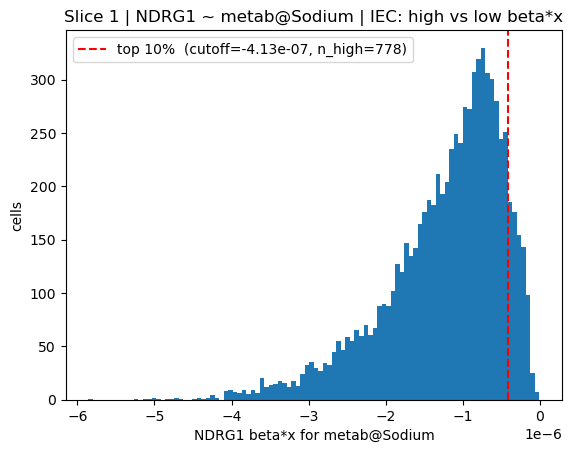

,names,scores,logfoldchanges,pvals,pvals_adj
0,FABP1,32.977730,2.549038,1.694381e-238,8.024589e-235
1,PHGR1,27.700144,1.391278,6.954437e-169,1.097874e-165
2,SLC26A2,23.159954,2.660349,1.153983e-118,1.093053e-115
3,KRT20,22.439697,2.535810,1.613412e-111,1.273520e-108
4,SLC26A3,19.158989,2.563829,8.143909e-82,5.509936e-79
5,SLC9A3,17.597961,2.406046,2.553541e-69,1.511696e-66
6,MALL,14.041297,2.564204,8.710410e-45,4.125250e-42
7,ANPEP,14.007973,0.733947,1.393253e-44,5.998586e-42
8,SELENBP1,12.283514,1.418801,1.110666e-34,3.506743e-32
9,AQP8,11.690047,1.950376,1.433073e-31,3.572123e-29


In [27]:
# Example: split IEC cells by NDRG1's beta*x for Sodium (top 10%), then DGE high vs low.
# DGE reads the log_normalized_counts layer by default (adata.X is raw counts).
grp, cutoff = split_cells_by_betax(adata, GENE, 'metab@Sodium',
                                   TIER,
                                   cell_types=['IEC'], frac=0.9)
dge_betax_groups(grp, n_genes=20)

## Per-sample differential expression\n\nSplit each loaded sample's cells high/low by the primary `GENE`'s beta*x for a metabolite, then run Wilcoxon DGE -- looped over every sample in `ADATAS`.

In [25]:
# DGE (high vs low beta*x) for GENE / DGE_METAB, run on every loaded sample.
from IPython.display import display

DGE_METAB = 'metab@Sodium'
for name, ad in ADATAS.items():
    try:
        grp, cut = split_cells_by_betax(ad, GENE, DGE_METAB, TIER, cell_types=[CELL_TYPE], frac=0.9, plot=False)
    except (KeyError, ValueError) as e:
        print(f'{name}: skipped -- {e}'); continue
    print(f'=== {name}: {GENE} ~ {DGE_METAB} high vs low in {CELL_TYPE} (cutoff={cut:.3g}) ===')
    display(dge_betax_groups(grp, n_genes=15))

=== Slice 1: NDRG1 ~ metab@Sodium high vs low in IEC (cutoff=-4.13e-07) ===


,names,scores,logfoldchanges,pvals,pvals_adj
0,FABP1,32.977730,2.549038,1.694381e-238,8.024589e-235
1,PHGR1,27.700144,1.391278,6.954437e-169,1.097874e-165
2,SLC26A2,23.159954,2.660349,1.153983e-118,1.093053e-115
3,KRT20,22.439697,2.535810,1.613412e-111,1.273520e-108
4,SLC26A3,19.158989,2.563829,8.143909e-82,5.509936e-79
5,SLC9A3,17.597961,2.406046,2.553541e-69,1.511696e-66
6,MALL,14.041297,2.564204,8.710410e-45,4.125250e-42
7,ANPEP,14.007973,0.733947,1.393253e-44,5.998586e-42
8,SELENBP1,12.283514,1.418801,1.110666e-34,3.506743e-32
9,AQP8,11.690047,1.950376,1.433073e-31,3.572123e-29


=== Slice 2: NDRG1 ~ metab@Sodium high vs low in IEC (cutoff=4.13e-06) ===


,names,scores,logfoldchanges,pvals,pvals_adj
0,SELENOP,28.934597,3.113054,4.384918e-184,2.076697e-180
1,AQP8,28.503864,4.571499,1.049102e-178,2.484273e-175
2,SLC26A3,26.142689,2.513735,1.193464e-150,1.884083e-147
3,GUCA2A,24.287687,2.827368,2.645111e-130,3.131812e-127
4,LYPD8,21.506395,3.398636,1.356429e-102,1.070675e-99
5,CA4,21.359940,3.397964,3.152159e-101,2.132661e-98
6,ANPEP,21.282064,3.124487,1.664503e-100,9.853857e-98
7,KRT20,20.516598,1.863588,1.530543e-93,8.054055e-91
8,NDRG1,19.183981,2.394538,5.037253e-82,2.385643e-79
9,PNPLA2,18.414051,2.425755,1.013485e-75,4.363514e-73


=== Slice 3: NDRG1 ~ metab@Sodium high vs low in IEC (cutoff=-8.58e-08) ===


,names,scores,logfoldchanges,pvals,pvals_adj
0,FABP1,8.357971,0.526539,6.380621e-17,1.007287e-13
1,KRT20,6.738114,0.934022,1.604558e-11,7.599185e-09
2,PHGR1,6.163795,0.264617,7.102174e-10,2.242393e-07
3,IGHA2,2.516295,2.215595,1.185957e-02,2.771911e-01
4,SLC9A3,2.468455,0.778052,1.356979e-02,3.031439e-01
5,SLC26A3,2.196016,0.630587,2.809083e-02,4.751363e-01
6,SLC26A2,1.967092,0.548072,4.917256e-02,6.468923e-01
7,MALL,1.542139,0.788968,1.230398e-01,1.000000e+00
8,GUCA2A,1.233924,0.821767,2.172313e-01,1.000000e+00
9,AQP8,1.179557,0.299258,2.381763e-01,1.000000e+00


=== Slice 4: NDRG1 ~ metab@Sodium high vs low in IEC (cutoff=1.62e-06) ===


,names,scores,logfoldchanges,pvals,pvals_adj
0,SELENOP,20.719423,2.578614,2.314434e-95,1.096116e-91
1,GUCA2A,19.131746,2.568863,1.373923e-81,3.253450e-78
2,AQP8,18.434397,5.420300,6.958969e-76,1.098589e-72
3,ANPEP,18.318254,3.182315,5.918149e-75,7.007088e-72
4,SLC26A3,18.192526,1.776214,5.914996e-74,5.602684e-71
5,CA4,16.369965,3.212039,3.133998e-60,2.473769e-57
6,PLAC8,14.691078,1.896020,7.353389e-49,4.975093e-46
7,LYPD8,13.969526,2.984158,2.392138e-44,1.258796e-41
8,HPGD,13.416341,2.222439,4.850794e-41,2.297336e-38
9,CEACAM1,13.144825,2.173745,1.822277e-39,7.845730e-37


In [26]:
modulators = [x for x in adata.uns['beta_modulators'][GENE] if x.startswith('metab@')]
for modulator in modulators:
    print(modulator)

metab@(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3-yl-b-D-Glucopyranosiduronic acid|1b,3a,12a-Trihydroxy-5b-cholanoic acid|3-Sulfodeoxycholic acid|3alpha,7alpha-Dihydroxycoprostanic acid|3b-Hydroxy-5-cholenoic acid|Chenodeoxycholic acid|Chenodeoxycholic acid 3-sulfate|Coprocholic acid|Deoxycholic acid|Folinic acid|Glutathione|Glycochenodeoxycholate-3-sulfate|Hyodeoxycholic acid|Isoursodeoxycholic acid|Lithocholic acid|Sulfolithocholic acid|Trihydroxycoprostanoic acid|Ursocholic acid|Ursodeoxycholic acid|Ursodeoxycholic acid 3-sulfate|Varanic acid
metab@17a-Ethynylestradiol|3',4'-Dihydrodiol|4'-Hydroxydiclofenac|4-Hydroxycyclophosphamide|8-Hydroxycarvedilol|E-3179|Estriol|Glycerol|N-Desmethylcitalopram|N-Desmethyleletriptan|O-Deethylated candesartan
metab@2-Hydroxychlorpropamide
metab@25-Hydroxycholesterol
metab@4-ene-Valproic acid
metab@5-Hydroxyomeprazole
metab@Acetate
metab@Acetyl-L-Carnitine|Choline|Creatine|Dopamine|Histamine|Norepinephrine
metab@Adenosine triphosphate
metab@Amil

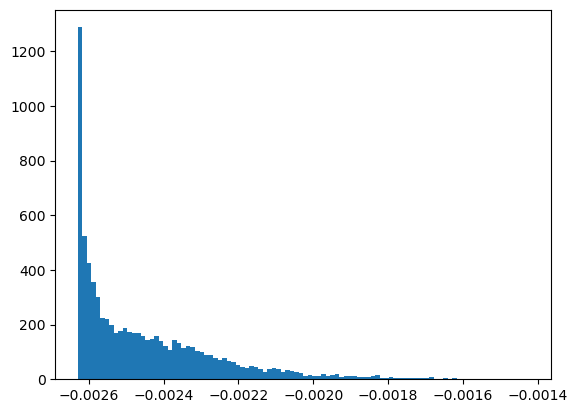

In [27]:
plt.hist(get_betas_modulator(adata, GENE, 'metab@Sodium', tier=TIER, cell_types=[CELL_TYPE]), bins=100);
# plt.hist(get_betas_modulator(adata, GENE, 'metab@Fatty Acid', tier=TIER, cell_types=[CELL_TYPE]))
# plt.hist(get_betas_modulator(adata, GENE, 'metab@Sodium', tier=TIER, cell_types=[CELL_TYPE]));
# plt.hist(get_betas_modulator(adata, GENE, 'metab@Sodium', tier=TIER, cell_types=[CELL_TYPE]));

In [28]:
harr_data_path = f'{DATA_DIR}/easy_download/harreman_outputs/[ccc_results][cell_com_df_m].csv'
harr_data = pd.read_csv(harr_data_path)
harr_data

,Unnamed: 0,Metabolite,C_p,Z,Z_pval,Z_FDR,C_np,pval_np,FDR_np,selected
0,0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",6561.722476,3.819081,6.697476e-05,1.924002e-04,4565.770532,0.000999,0.001902,True
1,1,17a-Ethynylestradiol,1087.732313,0.863965,1.938036e-01,2.861772e-01,6204.135907,0.000999,0.001902,True
2,2,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",6561.722476,3.819081,6.697476e-05,1.924002e-04,4565.770532,0.000999,0.001902,True
3,3,2-Hydroxychlorpropamide,983.805484,1.637178,5.079666e-02,9.787648e-02,8111.022841,0.000999,0.001902,True
4,4,25-Hydroxycholesterol,2345.571542,7.050788,8.895373e-13,9.369792e-12,2269.443120,0.002997,0.005571,True
...,...,...,...,...,...,...,...,...,...,...
153,153,Vitamin D3,2263.143662,6.803010,5.122786e-12,4.761178e-11,538.379201,0.000999,0.001902,True
154,154,Water,10068.549837,3.772934,8.066959e-05,2.276035e-04,130704.198027,0.000999,0.001902,True
155,155,Zinc,3985.656137,5.215775,9.152535e-08,5.561925e-07,2995.874037,0.000999,0.001902,True
156,156,alpha-Ketoisovaleric acid,1084.573588,3.260228,5.566131e-04,1.395950e-03,2595.406559,0.000999,0.001902,True


In [29]:
def _modulator_members(modulator):
    """'metab@A|B|C' -> ['A', 'B', 'C'] (exact whole-metabolite names)."""
    name = modulator.split('@', 1)[1] if '@' in modulator else modulator
    return name.split('|')


def mean_abs_coeff(adata, TARGET_GENE, modulator, tier=None, cell_types=None):
    tier = TIER if tier is None else tier
    cell_types = [CELL_TYPE] if cell_types is None else cell_types
    betas = np.nan_to_num(get_betas_modulator(adata, TARGET_GENE, modulator, tier, cell_types))
    return np.mean(np.abs(betas)), np.std(betas)


def extract_betas(TARGET_GENE, adata, harr=None, tier=None, cell_types=None):
    """One row per metabolite: avg |β|, β std, and both FDRs. Returns a DataFrame.
    harr/tier/cell_types default to the notebook globals (harr_data, TIER, CELL_TYPE); pass
    them explicitly (e.g. from plot_topk_all_samples) to run on another sample's data."""
    harr = harr_data if harr is None else harr
    modulators = adata.uns['beta_modulators'][TARGET_GENE]
    rows = []

    for metab in harr['Metabolite']:
        # EXACT membership, not substring: 'Adenosine' no longer matches
        # 'Adenosine triphosphate' or 'Adenosine diphosphate ribose'.
        match = [m for m in modulators if metab in _modulator_members(m)]

        if len(match) > 1:
            print(f"WARNING: {metab} matched multiple modulators: {match}")
            continue
        elif len(match) == 0:
            avg_coeff, std_coeff = 0.0, np.nan
        else:
            avg_coeff, std_coeff = mean_abs_coeff(adata, TARGET_GENE, match[0], tier, cell_types)

        h = harr.loc[harr['Metabolite'] == metab].iloc[0]
        rows.append({
            'metabolite': metab,
            'avg_coeff': avg_coeff,
            'std_coeff': std_coeff,
            'FDR_np': float(h['FDR_np']),
            'Z_FDR': float(h['Z_FDR']),
        })

    return pd.DataFrame(rows)


def plot_betas(df, fdr_col='Z_FDR', TARGET_GENE='', ax=None,
               labels=True, xlim=None, ylim=None):
    """Scatter avg |β| vs -log10(FDR). Set labels=False to hide text;
    pass xlim/ylim tuples to zoom."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    x = df['avg_coeff'].to_numpy()
    y = -np.log10(df[fdr_col].to_numpy())


    ax.scatter(x, y, s=30, alpha=0.8)
    ax.axhline(-np.log10(0.05), ls='--', lw=1, color='grey', label='FDR = 0.05')
    ax.axvline(0, ls=':', lw=1, color='grey')
    ax.set_xlabel('Average |modulator coefficient| (|β|)')
    ax.set_ylabel(f'-log10({fdr_col})')
    ax.set_title(f'{TARGET_GENE}: {fdr_col} vs avg |β|')
    ax.legend()

    if labels:
        for m, xi, yi in zip(df['metabolite'], x, y):
            if xi != 0:
                ax.annotate(m, (xi, yi), fontsize=7,
                            xytext=(3, 3), textcoords='offset points')

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    return ax

fdr_vs_bata_df = extract_betas('CD3E', adata)

In [30]:
def extract_betas_all(target_genes, adata):
    """{gene: DataFrame} — one extract_betas result per target gene."""
    return {gene: extract_betas(gene, adata) for gene in target_genes}


def plot_betas_grid(dfs, fdr_col='Z_FDR', labels=False, ncols=3,
                    xlim=None, ylim=None, figsize=None):
    """Plot every gene's df in a grid. `dfs` is the {gene: DataFrame} dict."""
    genes = list(dfs)
    ncols = min(ncols, len(genes))
    nrows = -(-len(genes) // ncols)  # ceil
    if figsize is None:
        figsize = (5 * ncols, 4 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for ax, gene in zip(axes, genes):
        plot_betas(dfs[gene], fdr_col=fdr_col, TARGET_GENE=gene, ax=ax,
                   labels=labels, xlim=xlim, ylim=ylim)

    for ax in axes[len(genes):]:  # hide unused panels
        ax.axis('off')

    fig.tight_layout()
    return fig, axes

genes = list(adata.uns['beta_modulators'])
dfs = extract_betas_all(genes, adata)

In [31]:
NDRG1_df = dfs[GENE]
NDRG1_df

,metabolite,avg_coeff,std_coeff,FDR_np,Z_FDR
0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",5.630703e-04,8.217793e-05,0.001902,1.924002e-04
1,17a-Ethynylestradiol,1.004591e-02,3.423900e-03,0.001902,2.861772e-01
2,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",5.630703e-04,8.217793e-05,0.001902,1.924002e-04
3,2-Hydroxychlorpropamide,1.537748e-02,4.343918e-03,0.001902,9.787648e-02
4,25-Hydroxycholesterol,3.534478e-05,1.400429e-05,0.005571,9.369792e-12
...,...,...,...,...,...
153,Vitamin D3,0.000000e+00,NaN,0.001902,4.761178e-11
154,Water,9.532682e-01,4.156162e-01,0.001902,2.276035e-04
155,Zinc,6.212905e-08,1.572782e-08,0.001902,5.561925e-07
156,alpha-Ketoisovaleric acid,4.840450e-04,1.919141e-04,0.001902,1.395950e-03


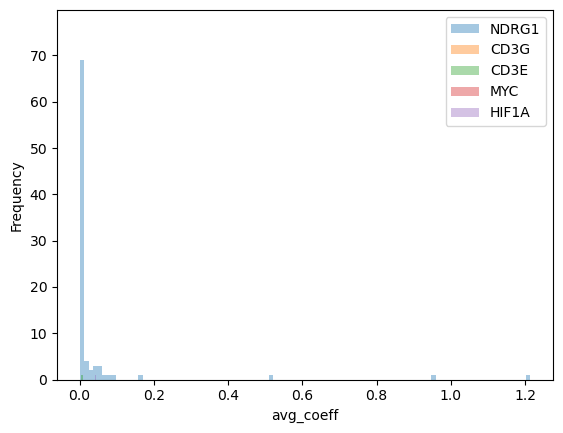

In [32]:
genes_to_plot = [GENE, 'CD3G', 'CD3E', 'MYC', 'HIF1A']

# 'negative_control': ['ACTB', 'B2M'],
#     'consistency': ['CD3D', 'CD3G', 'CD3E'],
#     'positive_control': ['MYC', 'HIF1A'],

for gene in genes_to_plot:
    # Filter out 0 values from avg_coeff
    coeffs = dfs[gene]['avg_coeff']
    non_zero_coeffs = coeffs[coeffs != 0]

    # Plot histogram
    plt.hist(non_zero_coeffs, bins=100, label=gene, alpha=0.4)

plt.legend()
plt.xlabel('avg_coeff')
plt.ylabel('Frequency')
plt.show()

In [33]:
# For each target gene: its k-th largest metabolite beta vs the variance of that gene's
# (log-normalized) expression. One point per gene. `dfs` is the extract_betas_all output above,
# so the beta used is `avg_coeff` (mean |beta| across the selected cells) per metabolite. A
# lighter, single-plot alternative to the per-gene histograms above: "do genes whose expression
# varies a lot also have a strong top metabolite coefficient?".
#   k=5          -> use the 5th largest metabolite beta (change k for 10th, etc.)
#   percentile=90 -> use the 90th-percentile beta instead (overrides k)
# adata.X is raw counts, so variance is taken on `layer` (default 'log_normalized_counts';
# layer=None uses .X). NOTE: `dfs` bakes in the cell type it was built with (extract_betas uses
# the notebook-global CELL_TYPE), so pass the SAME cell_types here, else beta_stat and variance
# come from different populations. `n_active` = metabolites with a non-zero beta for that gene.
def topk_beta_vs_variance(dfs, adata, tier, cell_types=None, k=5, percentile=None,
                          coeff_col='avg_coeff', layer='log_normalized_counts', plot=True):
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    rows = []
    for gene, df in dfs.items():
        if gene not in sub.var_names:
            continue
        c = df[coeff_col].to_numpy()
        c = c[c > 0]                      # drop metabolites with no modulator (beta == 0) for this gene
        if len(c) == 0:
            continue
        if percentile is not None:
            stat, label = np.percentile(c, percentile), f'{percentile}th-pct metabolite beta'
        else:
            kk = min(k, len(c))           # guard: fewer than k non-zero metabolites
            stat, label = np.sort(c)[::-1][kk - 1], f'{k}th-largest metabolite beta'
        col = sub[:, gene].X if layer is None else sub[:, gene].layers[layer]
        var = col.toarray().var()
        rows.append({'gene': gene, 'beta_stat': float(stat), 'variance': float(var),
                     'n_active': int(len(c))})
    out = pd.DataFrame(rows, columns=['gene', 'beta_stat', 'variance', 'n_active'])
    out = out.sort_values('beta_stat', ascending=False, ignore_index=True)

    if plot and len(out):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(out['variance'], out['beta_stat'], s=25)
        for _, r in out.iterrows():
            ax.annotate(r['gene'], (r['variance'], r['beta_stat']), fontsize=7)
        ax.set_xlabel(f'variance of log-norm expression ({cell_types})')
        ax.set_ylabel(label)
        ax.set_title(f'{adata.uns.get("sample","")} | {label} vs expression variance')
        plt.show()
    return out

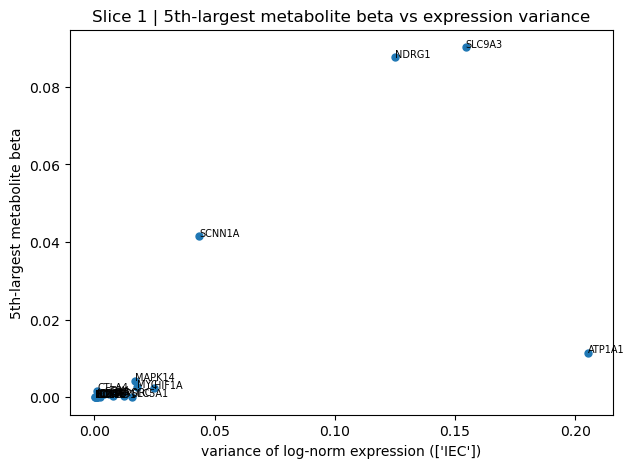

,gene,beta_stat,variance,n_active
0,SLC9A3,9.021463e-02,0.154394,88
1,NDRG1,8.763464e-02,0.125180,88
2,SCNN1A,4.157940e-02,0.043593,86
3,ATP1A1,1.149766e-02,0.205330,88
4,MAPK14,4.223100e-03,0.017009,83
5,MYC,2.659887e-03,0.017656,79
6,HIF1A,2.266125e-03,0.024943,82
7,CTLA4,1.703201e-03,0.001136,76
8,TOX,9.206455e-04,0.006092,48
9,SGK1,7.372224e-04,0.004064,49


In [34]:
# Example: 5th-largest metabolite beta per gene vs that gene's expression variance (IEC).
# Pass percentile=90 (etc.) to rank by a percentile of the betas instead of a fixed k.
topk_beta_vs_variance(dfs, adata, TIER, cell_types=[CELL_TYPE], k=5)
# topk_beta_vs_variance(dfs, adata, TIER, cell_types=[CELL_TYPE], percentile=90)

## All samples\n\nThe last plot (k-th largest metabolite beta vs gene-expression variance) across every **loaded** sample in `ADATAS` (reusing the single-sample logic). Comment out loads at the top to change the set.

In [35]:
# The last plot's logic (topk_beta_vs_variance) run across every loaded sample, one panel each.
# Rebuilds `dfs` per sample exactly like the single-sample path (extract_betas) and reuses
# topk_beta_vs_variance(..., plot=False) so the metric is identical -- just faceted by sample.
def plot_topk_all_samples(tier, cell_types=None, k=5, percentile=None, adatas=None, ncols=2):
    adatas = ADATAS if adatas is None else adatas
    label = f'{percentile}th-pct metab beta' if percentile is not None else f'{k}th-largest metab beta'
    ct = _ct_label(cell_types)
    n = len(adatas); nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, (name, ad) in zip(axes, adatas.items()):
        n_ct = ad.n_obs if cell_types is None else int(ad.obs[tier].isin(cell_types).sum())
        if n_ct == 0:                                          # this slice has none of these cell types
            ax.set_title(f'{name}: no {ct}'); ax.axis('off'); continue
        harr = pd.read_csv(f'{sample_dir(name)}/easy_download/harreman_outputs/[ccc_results][cell_com_df_m].csv')
        dfs = {g: extract_betas(g, ad, harr, tier, cell_types) for g in ad.uns['beta_modulators']}
        df = topk_beta_vs_variance(dfs, ad, tier, cell_types=cell_types, k=k, percentile=percentile, plot=False)
        ax.scatter(df['variance'], df['beta_stat'], s=25)
        for _, r in df.iterrows():
            ax.annotate(r['gene'], (r['variance'], r['beta_stat']), fontsize=7)
        ax.set_title(f'{name}  (n={n_ct} {ct})')
        ax.set_xlabel(f'variance of log-norm expr ({ct})'); ax.set_ylabel(label)
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(f'{label} vs expression variance across samples ({ct})')
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

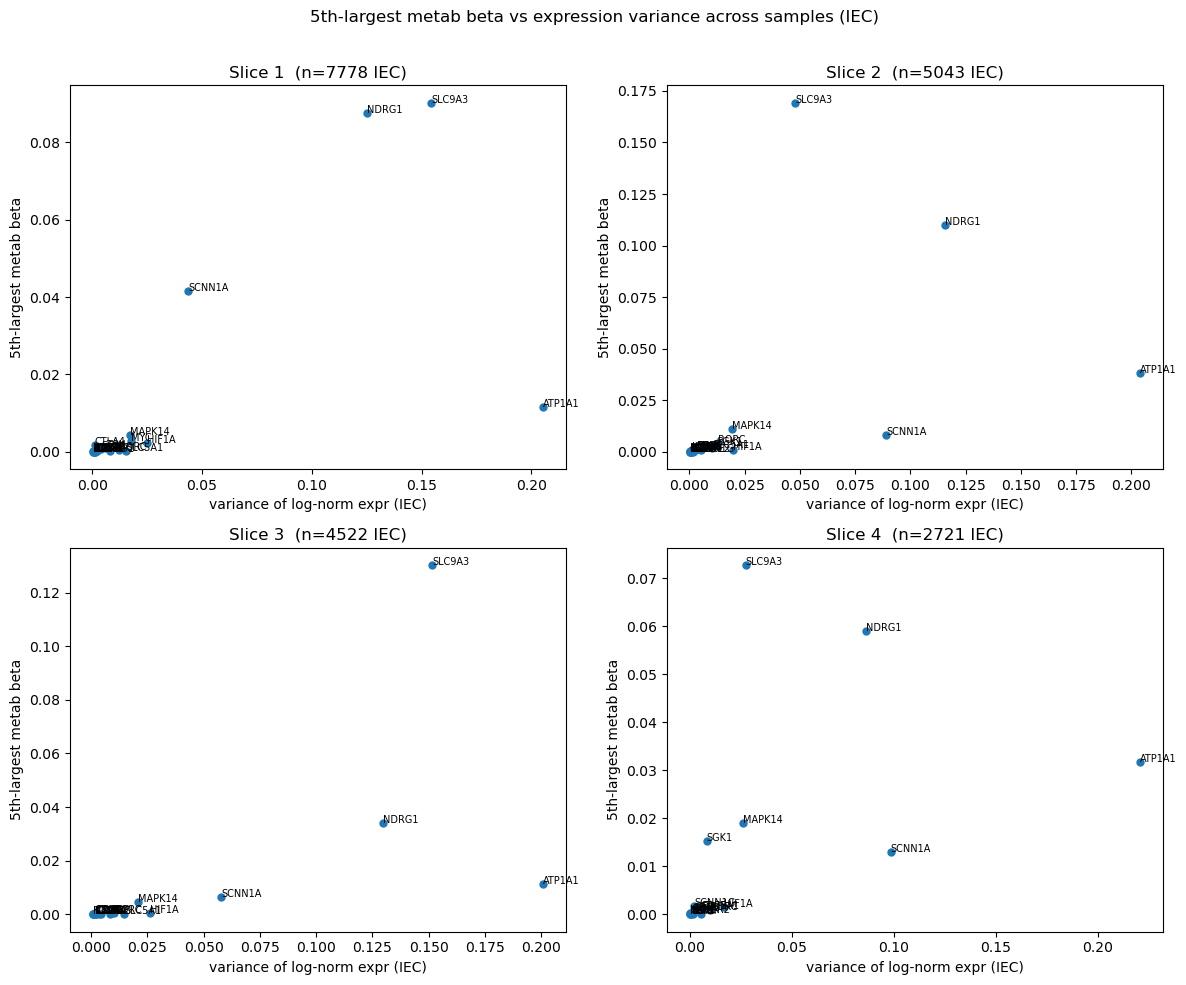

In [36]:
# The last plot, across all four slices. Uses the notebook's TIER/CELL_TYPE settings.
plot_topk_all_samples(TIER, cell_types=[CELL_TYPE], k=5)
# percentile instead of k:  plot_topk_all_samples(TIER, cell_types=[CELL_TYPE], percentile=90)